<a href="https://colab.research.google.com/github/MikeTX56/ML_Projects/blob/main/Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.simplefilter("ignore")
plt.style.use("fivethirtyeight")

In [3]:
!kaggle datasets download -d blastchar/telco-customer-churn

# Unzip the downloaded file
!unzip telco-customer-churn.zip

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100% 172k/172k [00:00<00:00, 126MB/s]

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [4]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
display(data.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


The `TotalCharges` column is currently of `object` type, but it should contain numerical values. This often happens when there are non-numeric characters (like spaces) or missing values represented as strings within the column. We will convert it to a numeric type and handle any non-numeric entries.

In [7]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors = 'coerce')

In [8]:
from IPython.core.interactiveshell import dis
missing_total_charges = data["TotalCharges"].isnull().sum()
print(f"Number of NaN vlues in totalcharges after conversion: {missing_total_charges}")


Number of NaN vlues in totalcharges after conversion: 11


In [9]:
if missing_total_charges > 0:
  print("\nRows with NaN in totalchares:")
  display(data[data["TotalCharges"].isnull()])


Rows with NaN in totalchares:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
data.dropna(inplace =True)

In [11]:
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
data.shape

(7032, 21)

In [13]:
def half_corr_heatmap(data, title = None):
  plt.figure(figsize=(9 ,9))
  sns.set(font_scale = 1)

  mask = np.zeros_like(data.corr())
  mask[np.tril_indices_from(mask)] = True

  with sns.axes_style("white"):
    sns.heatmap(data.corr(), mask = mask, annot = True, cmap = "coolwarm")
  if title:
    plt.title(f"\n{title}\n", fontsize = 18)
  plt.show()
  return

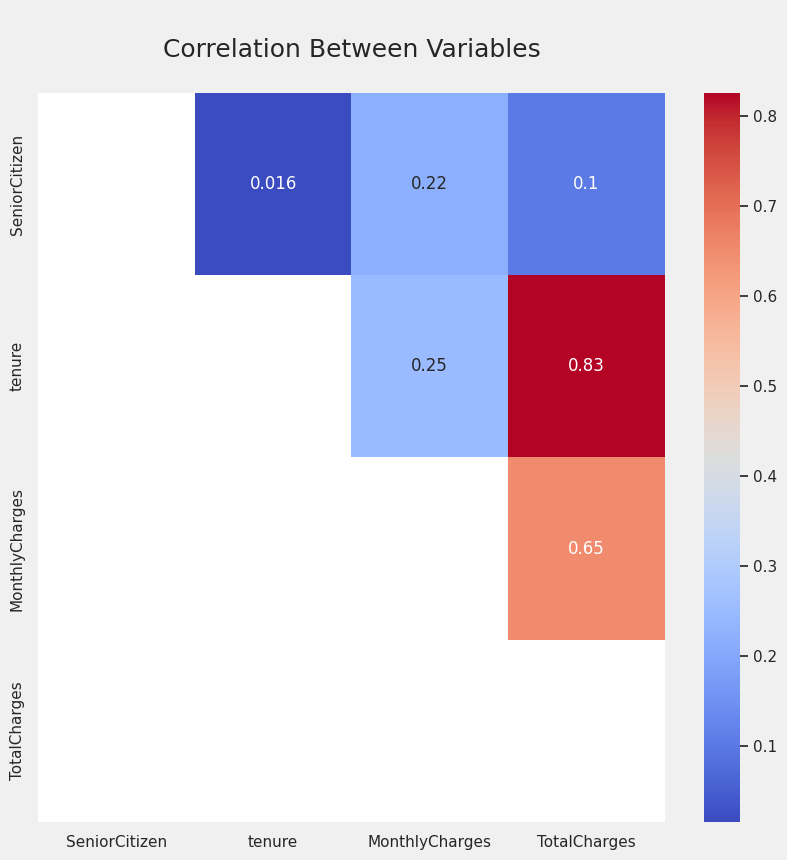

In [14]:
half_corr_heatmap(data.select_dtypes(include=np.number), 'Correlation Between Variables')

In [15]:
data.groupby("Churn")[['MonthlyCharges', 'tenure', 'TotalCharges']].agg(['min', 'max', 'mean'])

MonthlyCharges                    tenure                TotalCharges  \
                 min     max       mean    min max       mean          min   
Churn                                                                        
No             18.25  118.75  61.307408      1  72  37.650010        18.80   
Yes            18.85  118.35  74.441332      1  72  17.979133        18.85   

                             
           max         mean  
Churn                        
No     8672.45  2555.344141  
Yes    8684.80  1531.796094

In [16]:
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

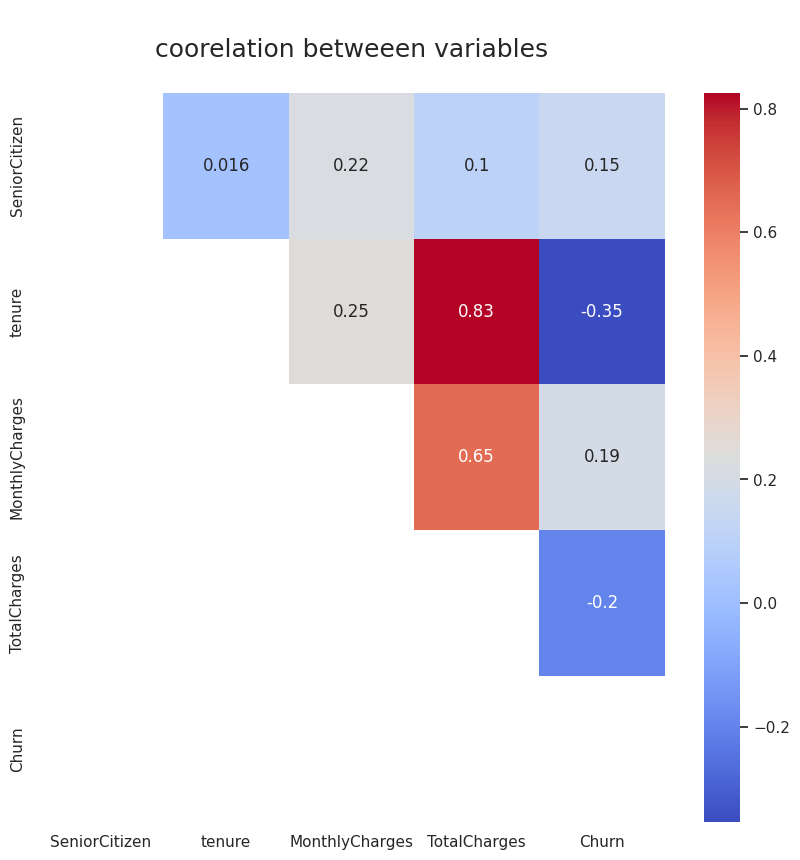

In [17]:
half_corr_heatmap(data.select_dtypes(include=np.number), "coorelation betweeen variables")

In [18]:
data.drop(["customerID"], axis = 1, inplace= True)

In [19]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [20]:
df = pd.get_dummies(data, drop_first = True)


Drop one level per categorical feature: To avoid perfect multicollinearity

In [21]:
for col in df.columns:
  if df[col].dtype == "bool":
    df[col] = df[col].astype(int)

In [22]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [23]:
for col in df.columns:
  print(df[col].unique(), "\n")

[0 1] 

[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39] 

[29.85 56.95 53.85 ... 63.1  44.2  78.7 ] 

[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ] 

[0 1] 

[0 1] 

[1 0] 

[0 1] 

[0 1] 

[1 0] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[1 0] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[0 1] 

[1 0] 

[0 1] 

[1 0] 

[0 1] 



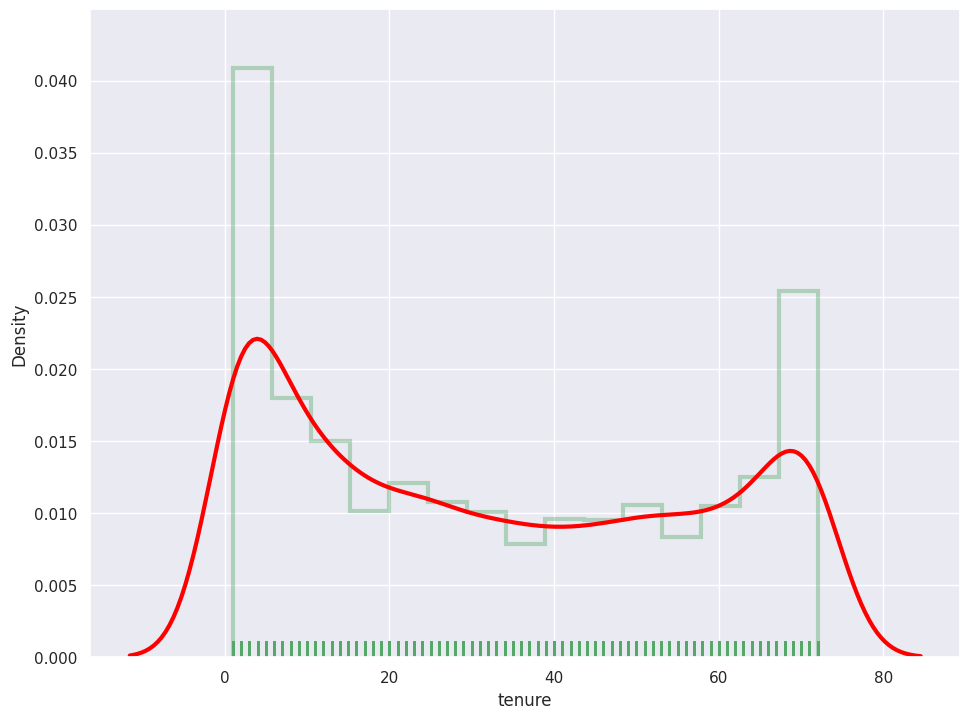

In [24]:
plt.figure(figsize = (10,8))

ax = sns.distplot(data['tenure'], rug=True, rug_kws={"color": "g"},
                  kde_kws={"color": "red", "lw": 3},
                  hist_kws={"histtype": "step", "linewidth": 3,
                            "alpha": 0.4, "color": "g"});

<Figure size 1200x800 with 0 Axes>

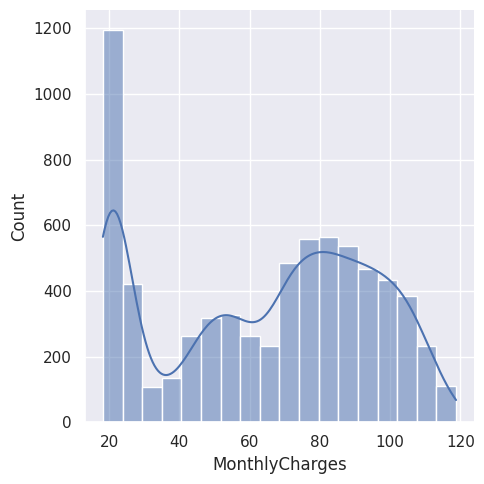

In [25]:
plt.figure(figsize = (12, 8))

sns.displot(data["MonthlyCharges"], kde = {"color": "red", "lw": 3});

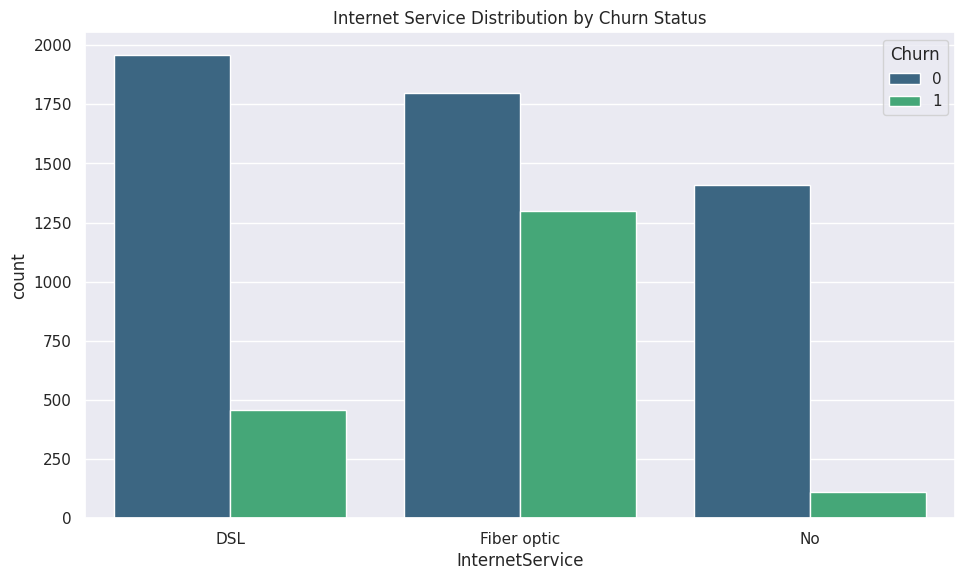

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(data = data, x = "InternetService", hue = 'Churn', palette='viridis')
plt.title('Internet Service Distribution by Churn Status');

This graph illustrates the distribution of customers across different Internet Service types, separated by their churn status. It clearly shows that customers with 'Fiber optic' internet service have a significantly higher churn rate compared to those with 'DSL' service or those who have 'No internet service'.

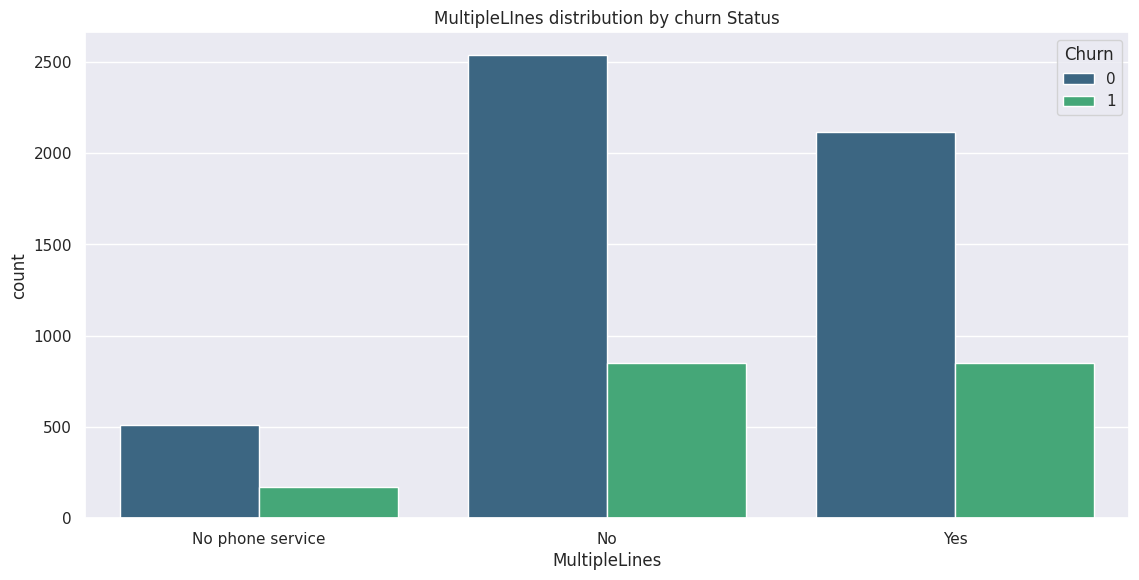

In [27]:
plt.figure(figsize = (12, 6))
sns.countplot(data = data, x = "MultipleLines", hue = "Churn", palette="viridis")
plt.title("MultipleLInes distribution by churn Status");

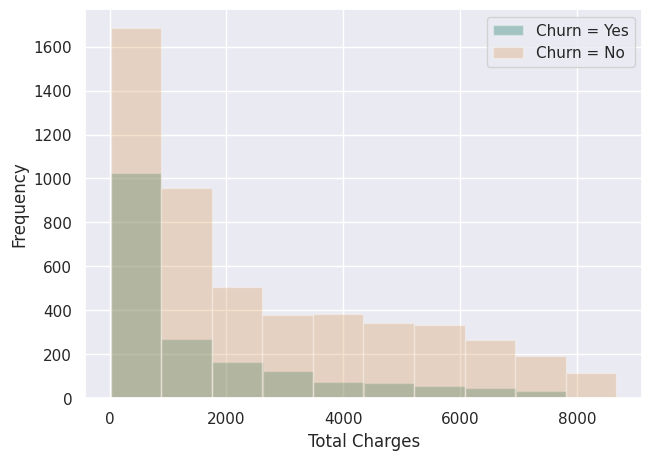

In [28]:
data[data['Churn'] == 1].TotalCharges.plot(kind = 'hist', alpha = 0.3, color = '#016a55', label = 'Churn = Yes')

data[data['Churn'] == 0].TotalCharges.plot(kind = 'hist', alpha = 0.3, color = '#d89955', label = 'Churn = No')

plt.xlabel('Total Charges')
plt.legend();

 This insight can help in developing targeted retention strategies. For instance, new customers or those with historically low `TotalCharges` might need more attention or incentives to encourage longer engagement and higher spending.

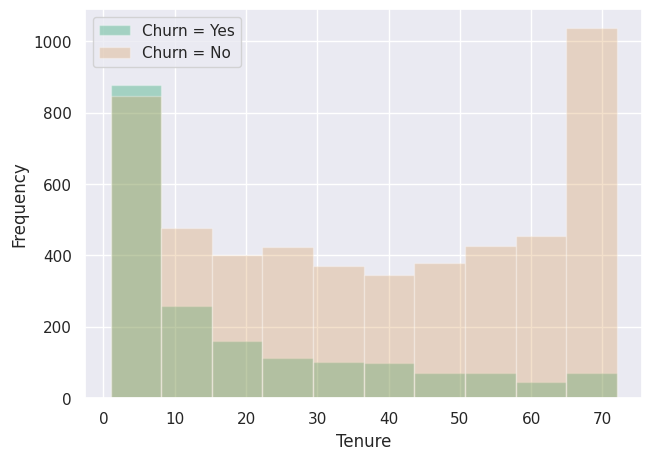

In [29]:
data[data['Churn'] == 1].tenure.plot(kind = 'hist', alpha = 0.3, color = '#019955', label = 'Churn = Yes')

data[data['Churn'] == 0].tenure.plot(kind = 'hist', alpha = 0.3, color = '#d89955', label = 'Churn = No')

plt.xlabel('Tenure')
plt.legend();

This suggests that intervention efforts to prevent churn should be prioritized for new customers or those still in their early months of service, as this is when they are most vulnerable to churn.

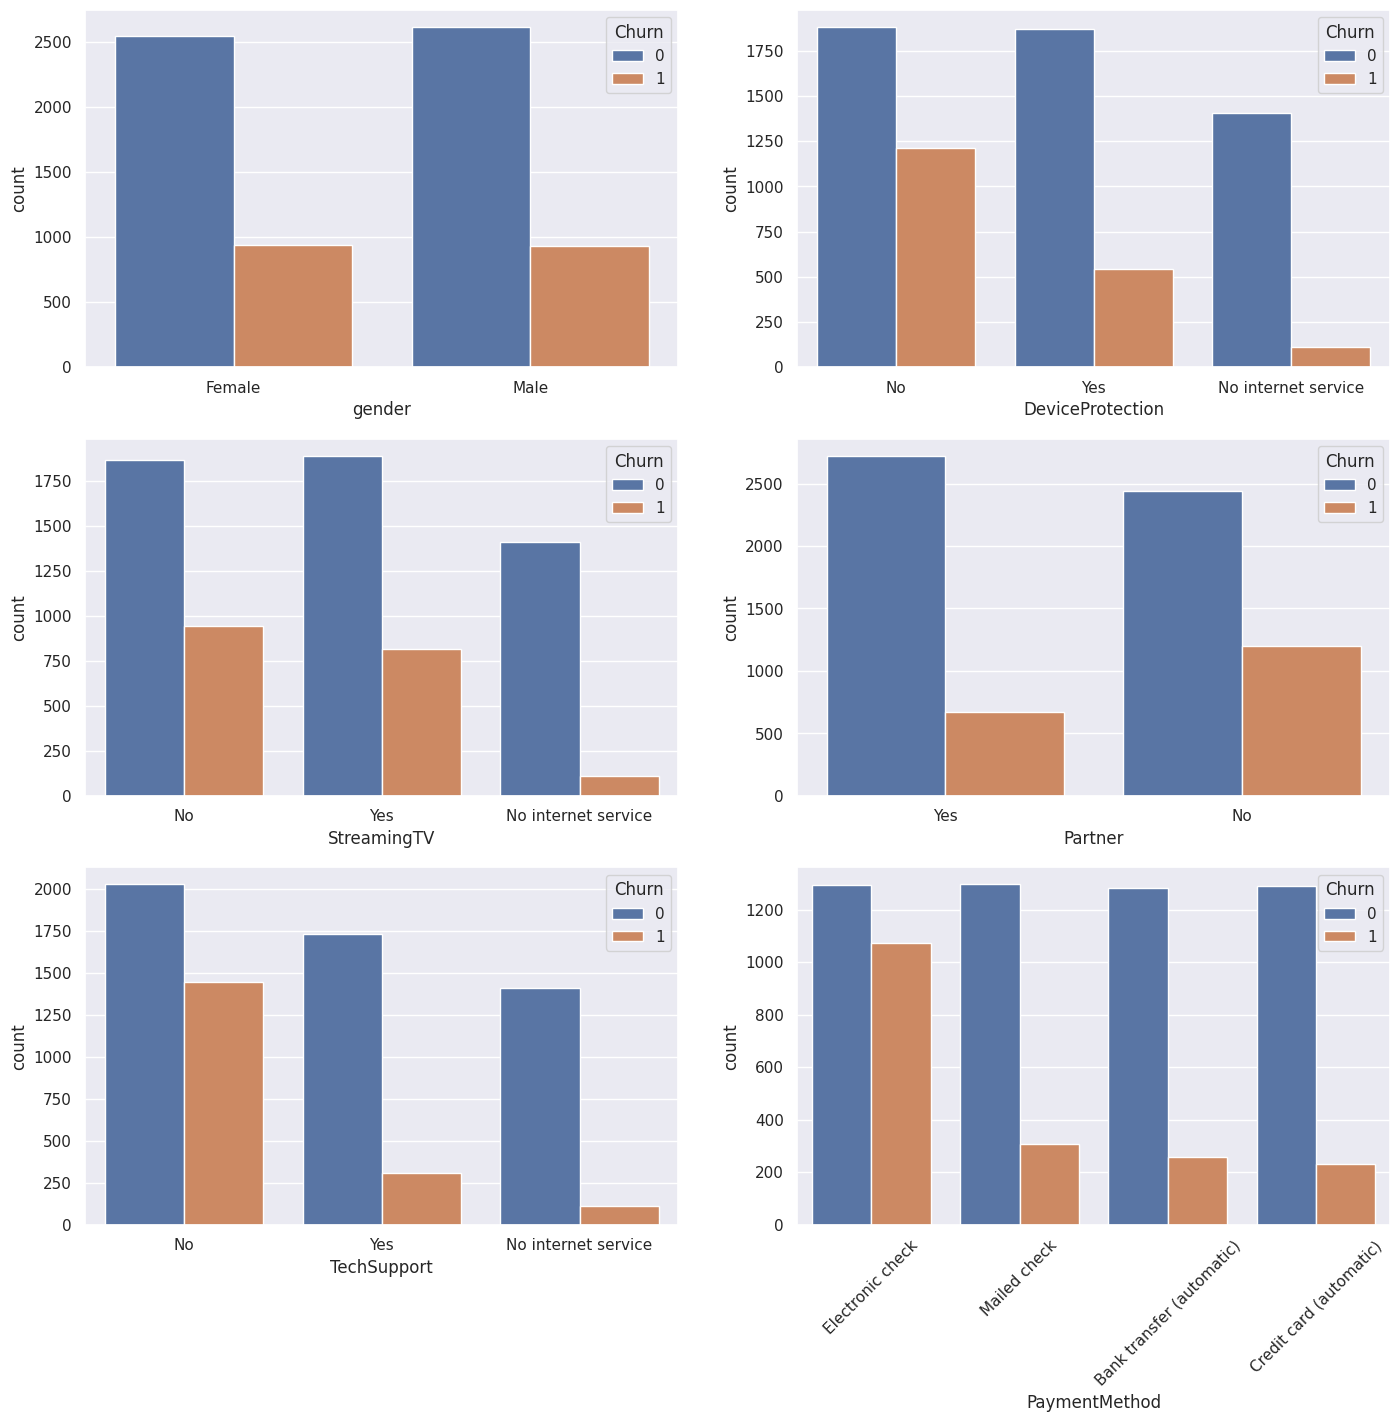

In [33]:
plt.figure(figsize = (15, 15))

plt.subplot(3, 2, 1)
sns.countplot(x ='gender', data = data, hue = 'Churn')

plt.subplot(3, 2, 2)
sns.countplot(x = 'DeviceProtection', data = data, hue = 'Churn')

plt.subplot(3, 2, 3)
sns.countplot(x = 'StreamingTV', data = data, hue = 'Churn')

plt.subplot(3, 2, 4)
sns.countplot(x = 'Partner', data = data, hue = 'Churn')

plt.subplot(3, 2, 5)
sns.countplot(x = 'TechSupport', data = data, hue = 'Churn')

plt.subplot(3, 2, 6)
sns.countplot(x = 'PaymentMethod', data = data, hue = 'Churn')

plt.xticks(rotation = 45);


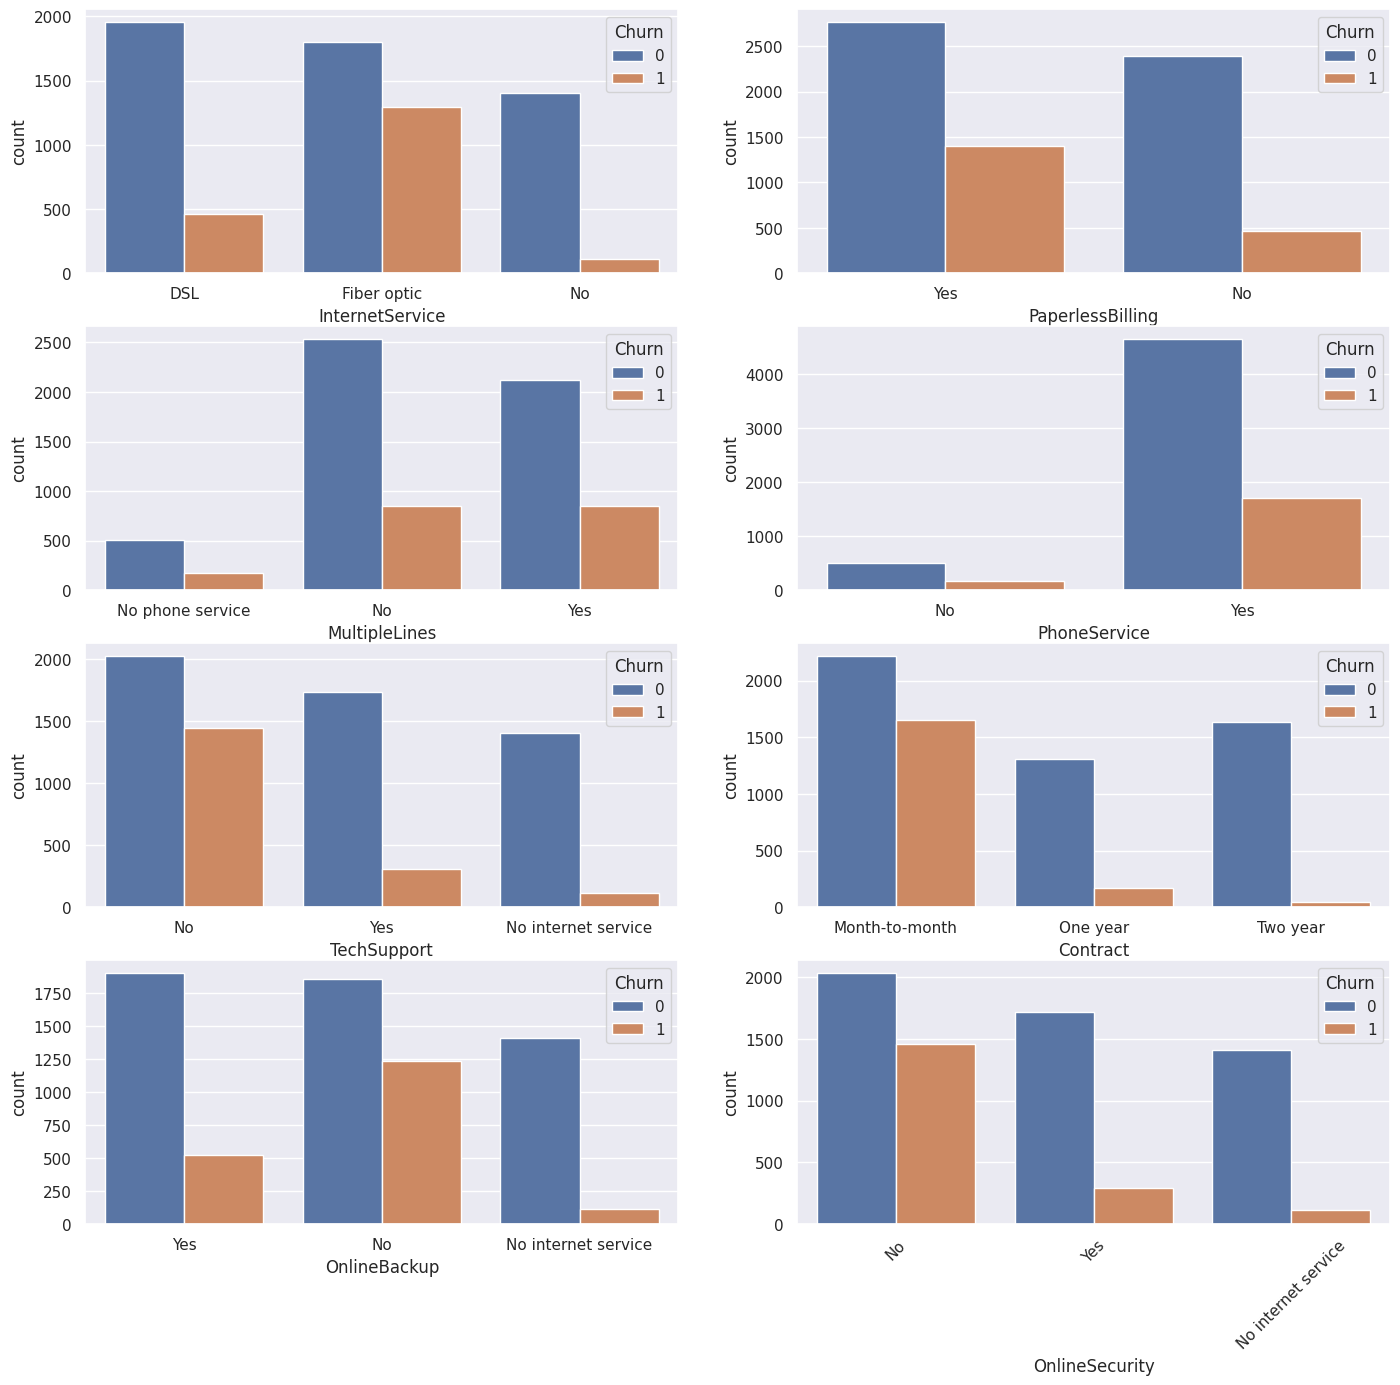

In [36]:
plt.figure(figsize = (15, 15))

plt.subplot(4, 2, 1)
sns.countplot(x ='InternetService', data = data, hue = 'Churn')

plt.subplot(4, 2, 2)
sns.countplot(x = 'PaperlessBilling', data = data, hue = 'Churn')

plt.subplot(4, 2, 3)
sns.countplot(x = 'MultipleLines', data = data, hue = 'Churn')

plt.subplot(4, 2, 4)
sns.countplot(x = 'PhoneService', data = data, hue = 'Churn')

plt.subplot(4, 2, 5)
sns.countplot(x = 'TechSupport', data = data, hue = 'Churn')

plt.subplot(4, 2, 6)
sns.countplot(x = 'Contract', data = data, hue = 'Churn')

plt.subplot(4, 2, 7)
sns.countplot(x = 'OnlineBackup', data = data, hue = 'Churn')

plt.subplot(4, 2, 8)
sns.countplot(x = 'OnlineSecurity', data = data, hue = 'Churn')
plt.xticks(rotation = 45);
